Dataset shape: (125, 90)

A2 – Regression Metrics
Train (MSE, RMSE, MAPE, R2): (2.179550473833658e-29, np.float64(4.668565597518855e-15), np.float64(2.0434833402536495e-12), 1.0)
Test  (MSE, RMSE, MAPE, R2): (0.08177209847749062, np.float64(0.2859582110684892), np.float64(43.66343466791225), 0.9166457438975826)

A3 – Full Feature Regression Metrics: (0.08177209847749062, np.float64(0.2859582110684892), np.float64(43.66343466791225), 0.9166457438975826)

Cluster Centers Shape: (2, 90)

A5 – Clustering Metrics (k=2)
Silhouette Score: 0.21778829111158232
Calinski-Harabasz: 34.25572823425737
Davies-Bouldin: 1.7499906205318547


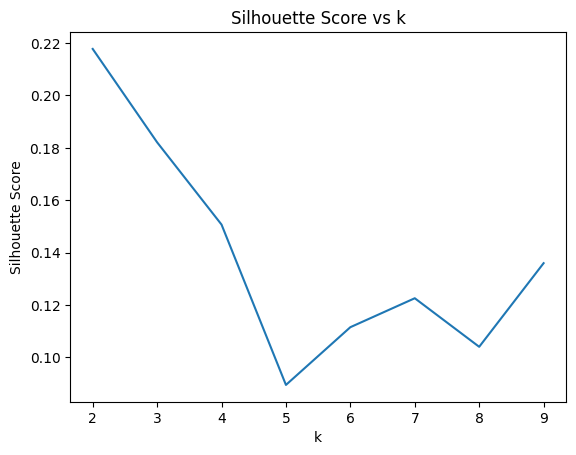

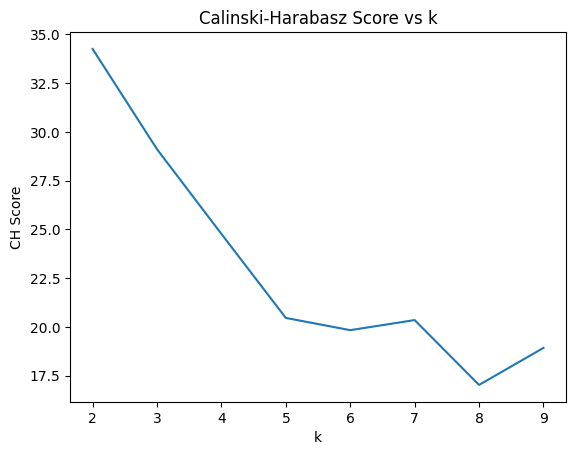

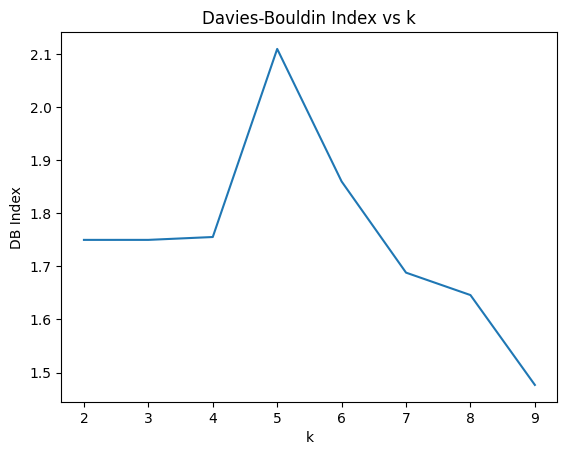

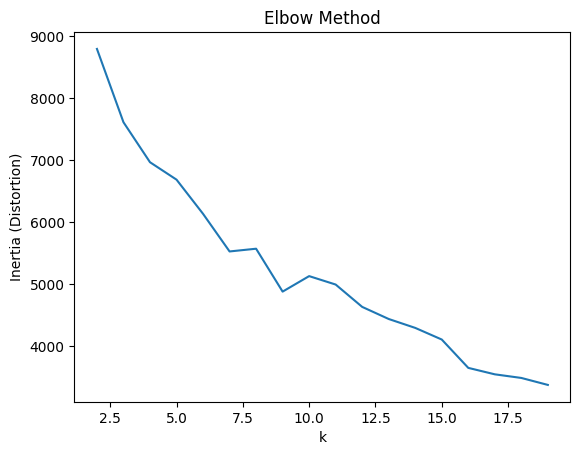

In [ ]:
# LAB 05 
import os

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from dataset import build_dataset, save_features



# A1 

def train_linear_regression(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


def predict_values(model, X):
    return model.predict(X)


# A2 

def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    epsilon = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mape, r2



# A4 

def perform_kmeans(X, k):
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    model.fit(X)
    return model



# A5 

def evaluate_clustering(X, labels):
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    return sil, ch, db



# A6 

def evaluate_multiple_k(X, k_values):
    silhouette_scores = []
    ch_scores = []
    db_scores = []

    for k in k_values:
        model = perform_kmeans(X, k)
        labels = model.labels_
        sil, ch, db = evaluate_clustering(X, labels)

        silhouette_scores.append(sil)
        ch_scores.append(ch)
        db_scores.append(db)

    return silhouette_scores, ch_scores, db_scores


# A7 


def elbow_method(X, k_values):
    distortions = []

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init="auto")
        model.fit(X)
        distortions.append(model.inertia_)

    return distortions



if __name__ == "__main__":

    
    dataset_path = "Lab2_Dataset"
    classes = sorted(os.listdir(dataset_path))
    X, y = build_dataset(dataset_path, classes)
    save_features(X, y)

  
    X = np.load("X_features.npy")
    y = np.load("y_labels.npy")

    print("Dataset shape:", X.shape)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # A1
   

    y_reg = X_scaled[:, 0]
    X_reg = X_scaled[:, 1:]

    X_train, X_test, y_train, y_test = train_test_split(
        X_reg, y_reg, test_size=0.3, random_state=42
    )

    model = train_linear_regression(X_train, y_train)

    y_train_pred = predict_values(model, X_train)
    y_test_pred = predict_values(model, X_test)

    train_metrics = evaluate_regression(y_train, y_train_pred)
    test_metrics = evaluate_regression(y_test, y_test_pred)

    print("\nA2 – Regression Metrics")
    print("Train (MSE, RMSE, MAPE, R2):", train_metrics)
    print("Test  (MSE, RMSE, MAPE, R2):", test_metrics)

    # A3
    X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
        X_scaled[:, 1:], X_scaled[:, 0], test_size=0.3, random_state=42
    )

    model_full = train_linear_regression(X_train_full, y_train_full)

    y_test_full_pred = predict_values(model_full, X_test_full)

    full_metrics = evaluate_regression(y_test_full, y_test_full_pred)

    print("\nA3 – Full Feature Regression Metrics:", full_metrics)

    # A4 
    kmeans_model = perform_kmeans(X_scaled, k=2)
    labels = kmeans_model.labels_

    print("\nCluster Centers Shape:", kmeans_model.cluster_centers_.shape)


    # A5 
    sil, ch, db = evaluate_clustering(X_scaled, labels)

    print("\nA5 – Clustering Metrics (k=2)")
    print("Silhouette Score:", sil)
    print("Calinski-Harabasz:", ch)
    print("Davies-Bouldin:", db)


    # A6 
    k_values = list(range(2, 10))

    sil_scores, ch_scores, db_scores = evaluate_multiple_k(X_scaled, k_values)

    plt.figure()
    plt.plot(k_values, sil_scores)
    plt.title("Silhouette Score vs k")
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.show()

    plt.figure()
    plt.plot(k_values, ch_scores)
    plt.title("Calinski-Harabasz Score vs k")
    plt.xlabel("k")
    plt.ylabel("CH Score")
    plt.show()

    plt.figure()
    plt.plot(k_values, db_scores)
    plt.title("Davies-Bouldin Index vs k")
    plt.xlabel("k")
    plt.ylabel("DB Index")
    plt.show()


    # A7 
    k_elbow = list(range(2, 20))
    distortions = elbow_method(X_scaled, k_elbow)

    plt.figure()
    plt.plot(k_elbow, distortions)
    plt.title("Elbow Method")
    plt.xlabel("k")
    plt.ylabel("Inertia (Distortion)")
    plt.show()